In [1]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
record = wfdb.rdrecord("../data/sleep_ecg_data/slp01a")
print(record.__dict__.keys())


dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])


In [3]:
signals = record.p_signal
print(record.sig_name)


['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']


In [4]:
ecg = record.p_signal[:, 0]
print(len(ecg))


1800000


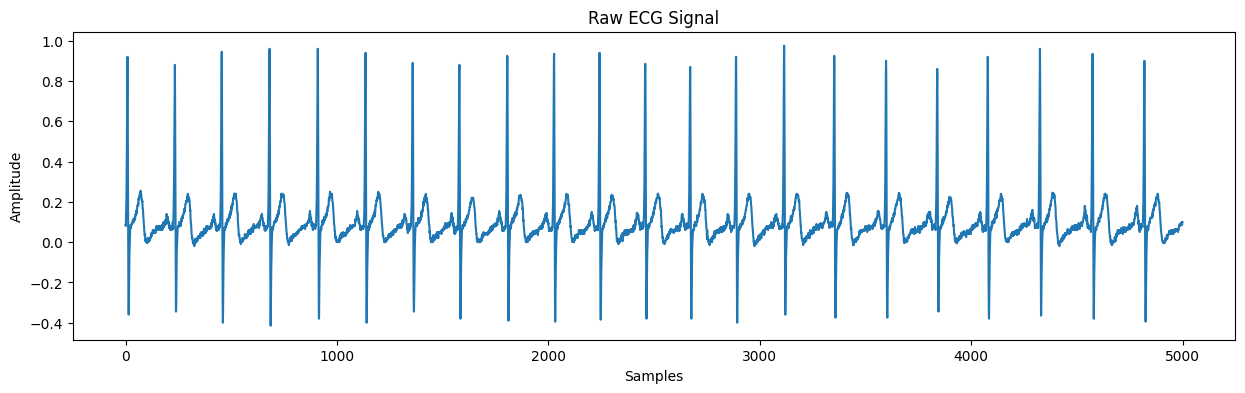

In [5]:
plt.figure(figsize=(15,4))
plt.plot(ecg[:5000])
plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


In [6]:
import neurokit2 as nk


In [7]:
cleaned_ecg = nk.ecg_clean(ecg, sampling_rate=100)


In [8]:
signals, info = nk.ecg_process(cleaned_ecg, sampling_rate=100)
rpeaks = info["ECG_R_Peaks"]

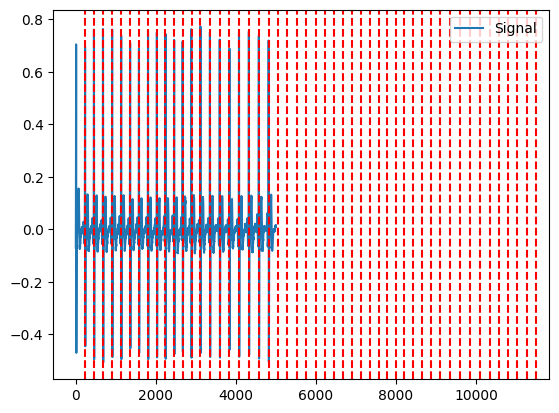

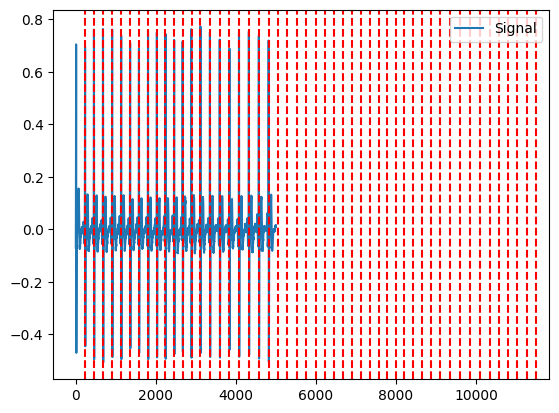

In [9]:
nk.events_plot(rpeaks[:50], cleaned_ecg[:5000])


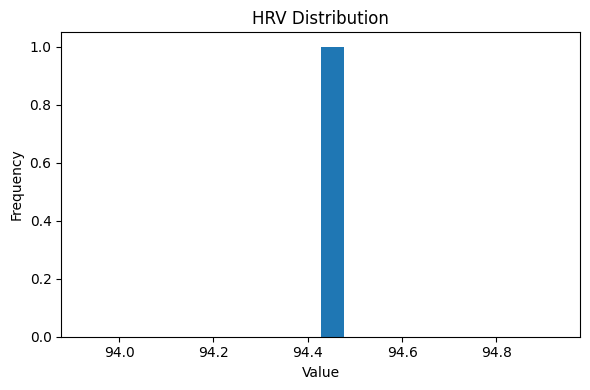

In [10]:
rr_intervals = nk.hrv_time(rpeaks, sampling_rate=100)

plt.figure(figsize=(6,4))
plt.hist(rr_intervals["HRV_RMSSD"], bins=20)
plt.title("HRV Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,66.774381,301.464971,0.2215,63240.690069,4.51468,5.507967,5444.071663,0.465563,0.423939,0.609324,...,0.81705,6.01465,0.597167,1.104391,1.447209,1.662184,0.921082,1.54248,2.485318,0.556781


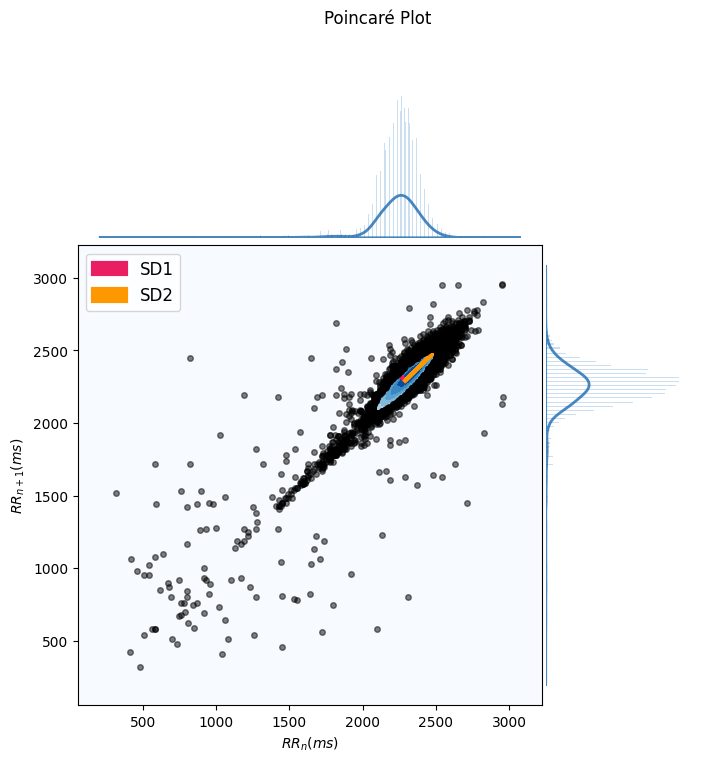

In [11]:
nk.hrv_nonlinear(rpeaks, sampling_rate=100, show=True)


,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF
0,0.000347,0.000892,0.000254,0.000045,0.000002,0.001539,5.672768,0.164736,0.02904,-10.015584


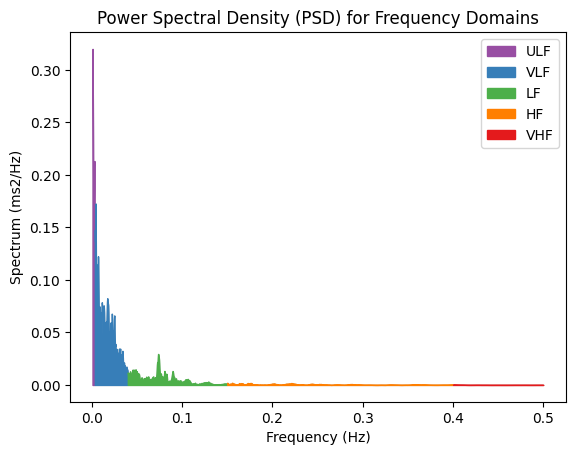

In [12]:
nk.hrv_frequency(rpeaks, sampling_rate=100, show=True)


In [13]:
hrv = nk.hrv(rpeaks, sampling_rate=100, show=False)
hrv.to_csv("../runs/hrv_slp01a.csv")
hrv.head()


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,2291.158498,218.323665,147.568063,108.337231,140.663658,119.546757,126.10013,138.902029,94.427227,94.433235,...,0.81705,6.01465,0.597167,1.104391,1.447209,1.662184,0.921082,1.54248,2.485318,0.556781


In [15]:
annotation = wfdb.rdann("../data/sleep_ecg_data/slp01a", "st")

In [16]:
print(annotation.__dict__.keys())


dict_keys(['record_name', 'extension', 'sample', 'symbol', 'subtype', 'chan', 'num', 'aux_note', 'fs', 'label_store', 'description', 'custom_labels', 'contained_labels', 'ann_len'])


In [17]:
print(annotation.aux_note[:30])


['4 LA LA', '4 LA', '4 LA', '4 L L L', '4 L', '4 L', '4 L L', '4 L', '4 L', '4 L L', '4 L L L', '4 LA', '3 HA', '3 H LA', '3 LA', '2 LA', '2 LA', '2 LA', '3 LA', '3 LA LA', '3 LA', '3 L LA', '3 LA', '3', '3 LA LA', '3 LA', '3 LA', '3 L', '3 L', '4 LA']


In [18]:
sleep_stages = []

for x in annotation.aux_note:
    first = x.split()[0]

    if first == 'W':          # Wake
        sleep_stages.append(0)
    elif first in ['1','2','3','4']:   # Sleep stages
        sleep_stages.append(int(first))
    else:
        continue              # Ignore MT and other notes

sleep_stages[:20]


[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 3, 3]

In [19]:
len(sleep_stages)

226

In [20]:
record.fs

250

In [21]:
samples_per_segment = 250 * 30  # 30 seconds
segments = []

for i in range(len(sleep_stages)):
    start = i * samples_per_segment
    end = start + samples_per_segment
    segment = ecg[start:end]
    
    if len(segment) == samples_per_segment:
        segments.append(segment)

len(segments)


226

In [29]:
import wfdb
import neurokit2 as nk
import pandas as pd

records = ["slp01a","slp02a","slp03","slp04"]

all_hrv = []

for rec in records:
    print("Processing:", rec)
    
    # Load ECG
    record = wfdb.rdrecord("../data/sleep_ecg_data/" + rec)
    ecg = record.p_signal[:,0]
    fs = record.fs
    
    # Load sleep annotations
    annotation = wfdb.rdann("../data/sleep_ecg_data/" + rec, "st")
    
    # Convert sleep stages
    sleep_stages = []
    for x in annotation.aux_note:
        first = x.split()[0]
        if first == 'W':
            sleep_stages.append(0)
        elif first in ['1','2','3','4']:
            sleep_stages.append(int(first))
        else:
            continue
    
    # Split ECG into 30-sec segments
    samples_per_segment = int(fs * 30)
    segments = []
    
    for i in range(len(sleep_stages)):
        start = i * samples_per_segment
        end = start + samples_per_segment
        segment = ecg[start:end]
        if len(segment) == samples_per_segment:
            segments.append(segment)
    
    # Extract HRV for each segment
    for segment, stage in zip(segments, sleep_stages):
        try:
            cleaned = nk.ecg_clean(segment, sampling_rate=fs)
            signals, info = nk.ecg_process(cleaned, sampling_rate=fs)
            rpeaks = info["ECG_R_Peaks"]
            hrv = nk.hrv(rpeaks, sampling_rate=fs, show=False)
            hrv["SleepStage"] = stage
            all_hrv.append(hrv)
        except:
            continue

hrv_dataset = pd.concat(all_hrv)
print("Dataset shape:", hrv_dataset.shape)


Processing: slp01a


/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) /

Processing: slp02a


/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term cor

Processing: slp03


/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term cor

Processing: slp04


/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term cor

Dataset shape: (1844, 83)


/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


In [30]:
hrv_dataset = hrv_dataset.dropna(axis=0, thresh=30)
hrv_dataset = hrv_dataset.fillna(hrv_dataset.mean())

hrv_dataset.shape

/home/saber/GitHub/HRV_stress_sleep/venv/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


(1844, 83)

In [31]:
hrv_dataset["SleepStage"].value_counts()


SleepStage
2    1065
0     364
1     184
3     163
4      68
Name: count, dtype: int64

In [32]:
def simplify(stage):
    if stage == 0:
        return "Wake"
    elif stage in [1,2]:
        return "Light"
    else:
        return "Deep"

hrv_dataset["StageSimple"] = hrv_dataset["SleepStage"].apply(simplify)
hrv_dataset.head()


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,SleepStage,StageSimple
0,919.354839,39.854359,NaN,NaN,NaN,NaN,NaN,NaN,21.614810,21.977627,...,1.070204,0.133895,0.163704,0.177036,2.005332,1.441130,1.890400,0.639251,4,Deep
0,919.354839,52.956302,NaN,NaN,NaN,NaN,NaN,NaN,29.430143,29.386368,...,1.092330,0.000000,0.000000,0.000000,1.984989,1.658779,1.591874,0.958877,4,Deep
0,921.548387,43.422604,NaN,NaN,NaN,NaN,NaN,NaN,22.709763,23.049771,...,1.070798,0.000000,0.000000,0.000000,1.720887,1.398942,1.682036,1.118689,4,Deep
0,938.800000,66.661471,NaN,NaN,NaN,NaN,NaN,NaN,26.832816,26.912008,...,0.858958,0.000000,0.000000,0.000000,1.302697,1.299480,1.496819,0.817815,4,Deep
0,940.800000,34.222799,NaN,NaN,NaN,NaN,NaN,NaN,19.067937,18.973666,...,0.955146,0.133895,0.163704,0.177036,2.842507,1.599412,1.495423,1.144941,4,Deep


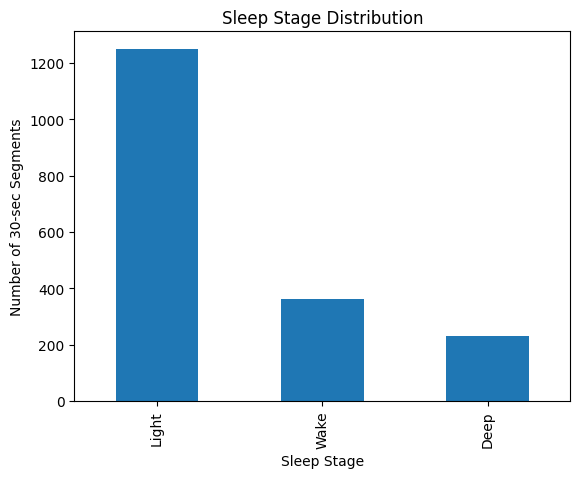

In [33]:
import matplotlib.pyplot as plt

hrv_dataset["StageSimple"].value_counts().plot(kind="bar")
plt.title("Sleep Stage Distribution")
plt.xlabel("Sleep Stage")
plt.ylabel("Number of 30-sec Segments")
plt.show()


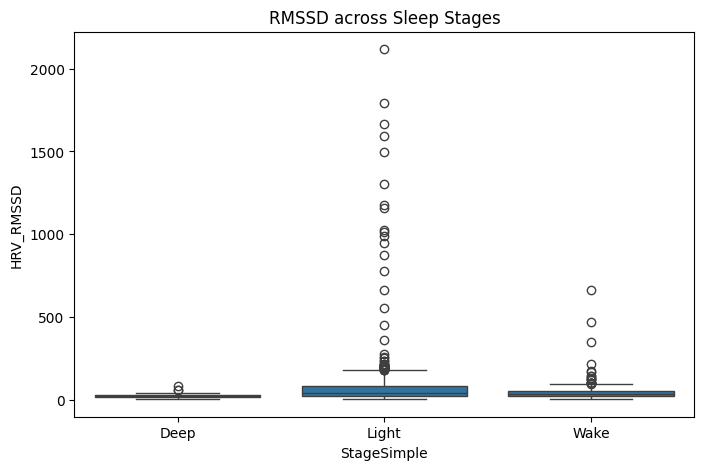

In [34]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="StageSimple", y="HRV_RMSSD", data=hrv_dataset)
plt.title("RMSSD across Sleep Stages")
plt.show()


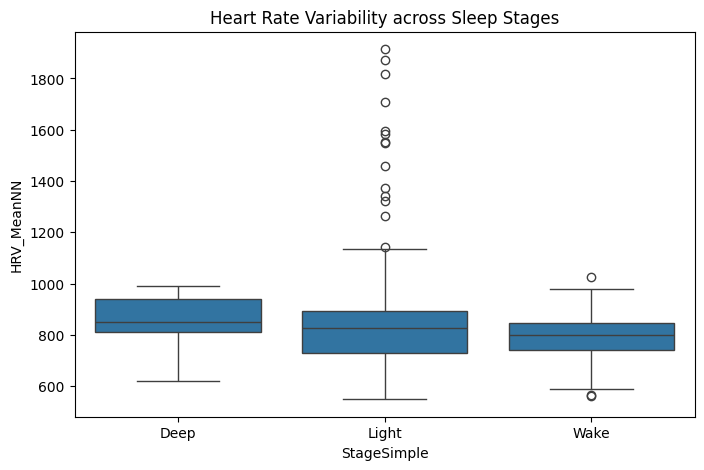

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x="StageSimple", y="HRV_MeanNN", data=hrv_dataset)
plt.title("Heart Rate Variability across Sleep Stages")
plt.show()


In [36]:
def simplify(stage):
    if stage == 0:
        return "Wake"
    elif stage in [1,2]:
        return "Light"
    else:
        return "Deep"

hrv_dataset["StageSimple"] = hrv_dataset["SleepStage"].apply(simplify)


In [37]:
# ----- FINAL MODEL USING FULL DATASET -----

# 1) Features
features = ["HRV_RMSSD","HRV_SDNN","HRV_MeanNN","HRV_LFHF","HRV_SD1","HRV_SD2"]
X = hrv_dataset[features]
y = hrv_dataset["StageSimple"]

# 2) Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Train model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# 4) Evaluate
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

        Deep       0.42      0.40      0.41        35
       Light       0.74      0.88      0.80       256
        Wake       0.42      0.18      0.25        78

    accuracy                           0.68       369
   macro avg       0.53      0.48      0.49       369
weighted avg       0.64      0.68      0.65       369



In [39]:
# Save model

import joblib
joblib.dump(model, "../runs/models/rf_sleep.joblib")

['../runs/models/rf_sleep.joblib']